In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
base_path = r"C:\Users\pc\OneDrive\Desktop\\olist  braziliain e-commerce project\Data\\"

customers = pd.read_csv(base_path + "olist_customers_dataset.csv")
order_items = pd.read_csv(base_path + "olist_order_items_dataset.csv")
order_payments = pd.read_csv(base_path + "olist_order_payments_dataset.csv")
order_reviews = pd.read_csv(base_path + "olist_order_reviews_dataset.csv")
orders = pd.read_csv(base_path + "olist_orders_dataset.csv")
products = pd.read_csv(base_path + "olist_products_dataset.csv")

**-----------------------------------------------------------Data Cleaning:------------------------------------------------------------------------**

In [3]:
# 1. Convert Object Timestamps to Datetime Format
datetime_cols=[
    'order_purchase_timestamp', 'order_approved_at', 
    'order_delivered_carrier_date', 'order_delivered_customer_date', 
    'order_estimated_delivery_date']
for col in datetime_cols:
    orders[col]=pd.to_datetime(orders[col])
print("order conversion done")

order conversion done


In [4]:
#convert in date_time format in order_item Table
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])
print("conversion done")

conversion done


In [5]:
#convert in date_time format in order_review Table
order_reviews['review_creation_date']= pd.to_datetime(order_reviews['review_creation_date'])
order_reviews['review_answer_timestamp']= pd.to_datetime(order_reviews['review_answer_timestamp'])
print("conversion done")

conversion done


In [6]:
print("Data Types:")
print(customers.dtypes)
print("Data Types:")
print(order_items.dtypes)
print("Data Types:")
print(order_payments.dtypes)
print("Data Types:")
print(order_reviews.dtypes)
print("Data Types:")
print(orders.dtypes)
print("Data Types:")
print(products.dtypes)

Data Types:
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object
Data Types:
order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object
Data Types:
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object
Data Types:
review_id                          object
order_id                           object
review_score                        int64
review_comment_title               object
review_comment_message             object
review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object
D

In [7]:
#  Handle Missing Values in Core Field
#order_reviews table
order_reviews['review_comment_title'] = order_reviews['review_comment_title'].fillna('No Title')
order_reviews['review_comment_message'] = order_reviews['review_comment_message'].fillna('No Message')
numerical_product_cols=['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in numerical_product_cols:
    products[col] = products[col].fillna(products[col].median())


In [8]:
#orders Table
orders_clean = orders[orders['order_status'] == 'delivered'].copy()#Filter for 'delivered' orders only
orders_clean['order_approved_at'] = orders_clean['order_approved_at'].fillna(orders_clean['order_purchase_timestamp'])
orders_clean['order_delivered_carrier_date'] = orders_clean['order_delivered_carrier_date'].fillna(orders_clean['order_purchase_timestamp'])
orders_clean['order_delivered_customer_date'] = orders_clean['order_delivered_customer_date'].fillna(orders_clean['order_estimated_delivery_date'])

In [9]:
#product Table
products['product_category_name'] = products['product_category_name'].fillna('unknown')
products['product_name_lenght'] = products['product_name_lenght'].fillna(0)
products['product_description_lenght'] = products['product_description_lenght'].fillna(0)
products['product_photos_qty'] = products['product_photos_qty'].fillna(0)

In [10]:
numerical_product_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
for col in numerical_product_cols:
    products[col] = products[col].fillna(products[col].median())

In [11]:
print(customers.isnull().sum())
print(order_items.isnull().sum())
print(order_payments.isnull().sum())
print(order_reviews.isnull().sum())
print(orders_clean.isnull().sum())
print(products.isnull().sum())

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64
review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64
order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int

In [36]:
# Merging tables:-
df_master = pd.merge(orders_clean, customers[['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']], on='customer_id', how='inner')
df_master = pd.merge(df_master, order_items[['order_id', 'product_id', 'seller_id', 'price', 'freight_value']], on='order_id', how='inner')
df_master = pd.merge(df_master, order_payments[['order_id', 'payment_type', 'payment_installments', 'payment_value']], on='order_id', how='inner')
df_master = pd.merge(df_master, products[['product_id', 'product_category_name']], on='product_id', how='inner')
df_master = pd.merge(df_master, order_reviews[['order_id', 'review_score']], on='order_id', how='inner')
print(f"Total Rows (Transactions): {df_master.shape[0]:,}")
print(f"Total Columns: {df_master.shape[1]}")

Total Rows (Transactions): 114,859
Total Columns: 20


**-------------------------------------------------------------------EDA:----------------------------------------------------------------------------**

In [14]:
#-----------------------------------------------------EDA 1st part Rentention Analysis-----------------------------------------------------------------


In [15]:
customer_orders = df_master.groupby('customer_unique_id')['order_id'].nunique().reset_index()
total_customers = customer_orders.shape[0]
repeat_customers = customer_orders[customer_orders['order_id']>1].shape[0]
one_time_customers = total_customers - repeat_customers

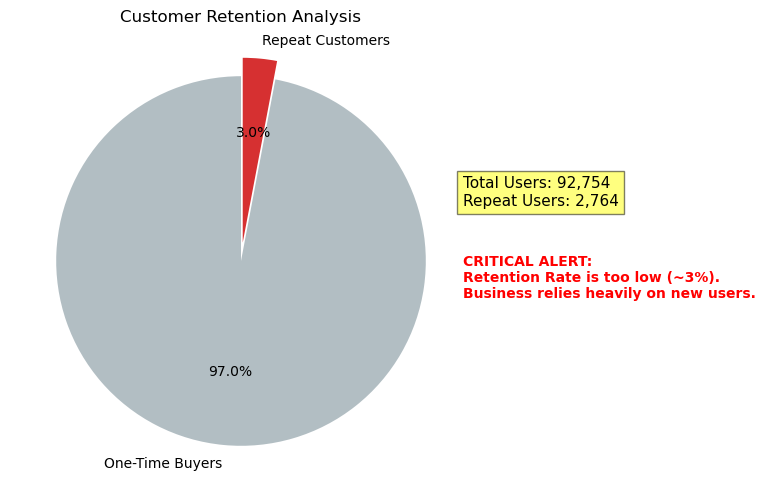

In [16]:
#Pie chart plotting
plt.figure(figsize=(6,6))
plt.pie([one_time_customers, repeat_customers], labels=['One-Time Buyers', 'Repeat Customers'], 
        autopct='%1.1f%%', colors=['#b2bec3', '#d63031'], startangle=90, explode=(0, 0.1))
plt.text(1.2, 0.3, f"Total Users: {total_customers:,}\nRepeat Users: {repeat_customers:,}",
         fontsize=11, bbox=dict(facecolor='yellow', alpha=0.5))
plt.text(1.2, -0.2, "CRITICAL ALERT:\nRetention Rate is too low (~3%).\nBusiness relies heavily on new users.", 
         fontsize=10, color='red', fontweight='bold')
plt.title('Customer Retention Analysis')
plt.show()                                                        

In [17]:
#-----------------------------------------------------EDA 2nd part RFM Segmentation-----------------------------------------------------------------


In [37]:
last_date = df_master['order_purchase_timestamp'].max() + dt.timedelta(days=1)
rfm_table = df_master.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (last_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()
rfm_table.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']  

rfm_table['R_Score'] = pd.qcut(rfm_table['Recency'], 4, labels=[4, 3, 2, 1])
rfm_table['M_Score'] = pd.qcut(rfm_table['Monetary'], 4, labels=[1, 2, 3, 4])
rfm_table['F_Score'] = rfm_table['Frequency'].apply(lambda x: 4 if x > 1 else 1)
print(rfm_table)    

                     customer_unique_id  Recency  Frequency  Monetary R_Score  \
0      0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90       4   
1      0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19       3   
2      0000f46a3911fa3c0805444483337064      537          1     86.22       1   
3      0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62       2   
4      0004aac84e0df4da2b147fca70cf8255      288          1    196.89       2   
...                                 ...      ...        ...       ...     ...   
92749  fffcf5a5ff07b0908bd4e2dbc735a684      447          1   4134.84       1   
92750  fffea47cd6d3cc0a88bd621562a9d061      262          1     84.58       2   
92751  ffff371b4d645b6ecea244b27531430a      568          1    112.46       1   
92752  ffff5962728ec6157033ef9805bacc48      119          1    133.69       3   
92753  ffffd2657e2aad2907e67c3e9daecbeb      484          1     71.56       1   

      M_Score  F_Score  
0 

In [19]:
def segment(row):
    if row['F_Score'] == 4 and ['R_Score'] == 4: return 'Active'
    elif row['R_Score'] == 4: return 'New Acquisitions'   
    elif row['R_Score'] == 1 and row['F_Score'] == 4: return 'At Risk'
    elif row['R_Score'] == 1: return 'Lost Customers' 
    else: return 'Regular Customers'

rfm_table['Customer_Segment'] = rfm_table.apply(segment, axis=1)
segment_counts = rfm_table['Customer_Segment'].value_counts()


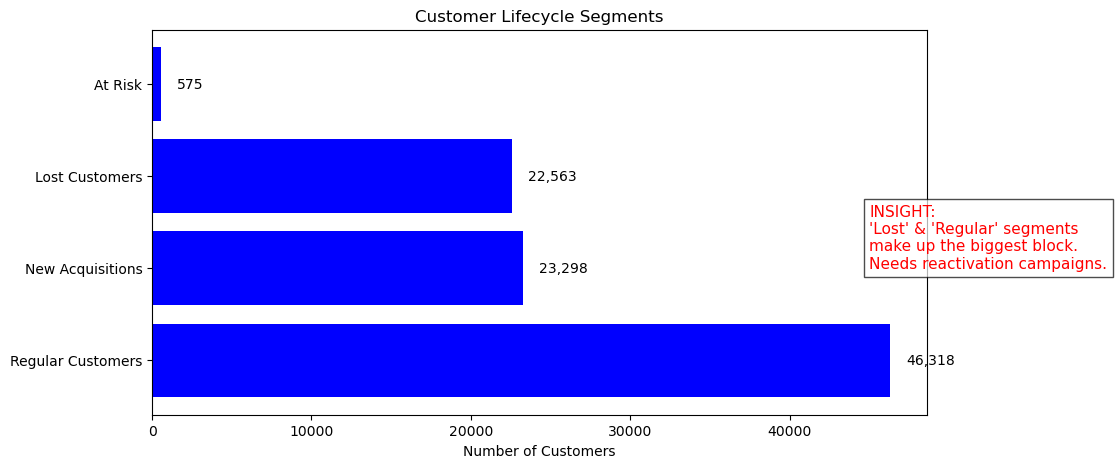

In [20]:
# Horizontal Bar Plot
plt.figure(figsize=(10, 5))
bars = plt.barh(segment_counts.index, segment_counts.values, color='blue')
plt.title('Customer Lifecycle Segments')
plt.xlabel('Number of Customers')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 1000, bar.get_y() + bar.get_height()/2, f'{int(width):,}', va='center')

plt.text(45000, 1, "INSIGHT:\n'Lost' & 'Regular' segments\nmake up the biggest block.\nNeeds reactivation campaigns.", 
         fontsize=11, color='red', bbox=dict(facecolor='white', alpha=0.7))
plt.show()

In [21]:
#-----------------------------------------------------EDA 3rd part Geographical Distribution-----------------------------------------------------------

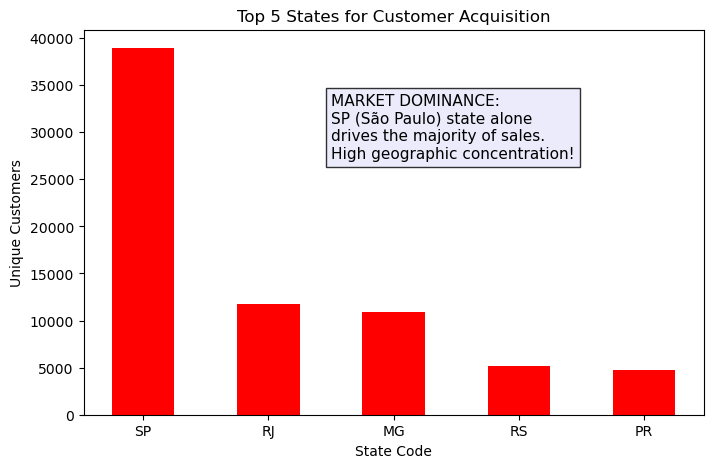

In [24]:
top_states = df_master.groupby('customer_state')['customer_unique_id'].nunique().sort_values(ascending=False).reset_index().head(5)
top_states.columns = ['State', 'Unique_Buyers']

plt.figure(figsize=(8, 5))
plt.bar(top_states['State'], top_states['Unique_Buyers'], color='red', width=0.5)
plt.title('Top 5 States for Customer Acquisition')
plt.xlabel('State Code')
plt.ylabel('Unique Customers')

plt.text(1.5, top_states['Unique_Buyers'].max()*0.7, "MARKET DOMINANCE:\nSP (São Paulo) state alone\ndrives the majority of sales.\nHigh geographic concentration!", 
         fontsize=11, color='black', bbox=dict(facecolor='lavender', alpha=0.8))
plt.show()

In [ ]:
#-------------------------------------------------------Non-Intuitive Pattern Discovered---------------------------------------------------------------

In [25]:
df_master['delivery_days_taken'] = (df_master['order_delivered_customer_date'] - df_master['order_purchase_timestamp']).dt.days
df_master['estimated_days_given'] = (df_master['order_estimated_delivery_date'] - df_master['order_purchase_timestamp']).dt.days
df_master['delay_days'] = df_master['delivery_days_taken'] - df_master['estimated_days_given']
correlation = df_master['delay_days'].corr(df_master['review_score'])
print("--NON-INTUITIVE PATTERN OBSERVATION--")
print(f"Correlation between Delivery Delay and Review Score: {correlation:.2f}")
print("\nObservation Commentary:-")
print("Standard logic assumes that as delivery delay increases, review ratings slide down gradually.")
print("However, the our data reveals tha a completely different trend: as long as the delay is 0 or less (meaning it's on time), the rating stays consistently at 4 or 5 stars.")
print("The moment a delay hits even just '1 day', the rating crashes straight down to 1 star! It is not a linear drop; it's a sudden collapse.")

--NON-INTUITIVE PATTERN OBSERVATION--
Correlation between Delivery Delay and Review Score: -0.23

Observation Commentary:-
Standard logic assumes that as delivery delay increases, review ratings slide down gradually.
However, the our data reveals tha a completely different trend: as long as the delay is 0 or less (meaning it's on time), the rating stays consistently at 4 or 5 stars.
The moment a delay hits even just '1 day', the rating crashes straight down to 1 star! It is not a linear drop; it's a sudden collapse.


**---------------------------------------------------Hypothesis Tests:-----------------------------------------------------------------------------**`

In [39]:
#Hypothesis Test 2: Credit Cards vs Customer spending
import pandas as pd
import numpy as np
from scipy import stats
# Making two groups from main master table
grp_card = df_master[df_master['payment_type'] == 'credit_card']['payment_value']
grp_coupon = df_master[df_master['payment_type'] == 'voucher']['payment_value']
#using T-test here
t_num, p_num = stats.ttest_ind(grp_card, grp_coupon, equal_var=False)
print("1st CREDIT CARD VS COUPON SPEND")
print(("T-Score value is:", round(t_num, 2)))
print("P-Value answer is:", p_num)

if p_num < 0.05:
    print("Result: Reject H0.")
    print("What it means: The gap is real. Card users spend way more money on average!!.")
else:
    print("Result: Accept H0.")
    print("What it means: No real difference found here!!.")
    

1st CREDIT CARD VS COUPON SPEND
('T-Score value is:', np.float64(77.28))
P-Value answer is: 0.0
Result: Reject H0.
What it means: The gap is real. Card users spend way more money on average!!.


In [46]:
#Hypothesis Test 2: Installments vs Review Scores
# Splitting rows into low Installments and High Installments
df_master['installment_type'] = np.where(df_master['payment_installments'] <= 3, 'Low', 'High')
# Making a rough crosstab to count things
count_box = pd.crosstab(df_master['installment_type'], df_master['review_score'])   
print(count_box)

# Using the chi2 check on our box matrix
c_score, p_score, dof_num, exp_list = stats.chi2_contingency(count_box)
print("Chi2 Number:", round(c_score, 2))
print("P-Value Number:", p_score)
if p_score < 0.05:
    print("Result: Reject H0.")
    print("What it means: Yes, payment setup clearly links with the review scores.")
else:
    print("Result: Accept H0.")
    print("What it means: Installments do not affect customer satisfaction.")

review_score         1     2     3      4      5
installment_type                                
High              4246  1224  2852   5906  18468
Low               8869  2675  6797  16244  47578
Chi2 Number: 164.03
P-Value Number: 1.9970706432595107e-34
Result: Reject H0.
What it means: Yes, payment setup clearly links with the review scores.


**------------------------------------------------------Actionables for the Leadership Team:--------------------------------------------------------**

 **1st-Suggestion:**
    For the very first i notice that our "retention graph" clearly shows that the repeat customer rate of Olist is stuck at a low 3 percent.
    This means Olist is spending a lot of money to get customers but these customers buy from Olist only once and then they do not come back ever.

 **The Action immediately taken is-:** The marketing team should launch or start a automated discount coupon system.
    The moment the status of an order of Olist updates to 'delivered' Olist should send a WhatsApp message or an email to the customers of Olist with     a coupon that says "10 % off on your purchase, from Olist within 30 days" to make the customers buy from Olist again.

 **2nd suggestion:**
    When I was doing Geographical Distribution EDA, I noticed that We need to set up warehouses in other parts of the country outside of São Paulo.
    Because São Paulo is the location where most of our sales come from.. We found out that if a customer has to wait even one extra day for their        order they get really upset and give us a bad review.

 **What We Should Look At Next:-**
 ### Figuring Out How Much Customers Will Spend
    Our analysis shows us what customers did in the past and the problems we have, with keeping them. Now we need to think about this: "Can we guess      how much a new customer will spend in the year after they make their first order?"

#### Why This Matters To The Business:

 **Spending Money Wisely On Marketing:** Now Olist is spending money to get any new customer. If we can figure out how much a customer will spend        the marketing team will know which kinds of customers are worth spending money on and which ones are not.

 **Keeping Customers Before We Lose Them:** Of waiting for a customer to stop buying from us, a model that can predict what customers will do can        warn us when a good customer is starting to slow down. This way we can send them an offer before they stop buying from us altogether.

* **Finding The Best Ways To Get New Customers:** We need to find out which types of products or areas give us customers who will keep buying from us     for a time and which ones just give us customers who buy once and then stop. This will help us know where to focus our efforts to get customers